## היסטוגרמה: bins, density

היסטוגרמה מציגה את **התפלגות** ערכי מדגם — כמה תוצאות נפלו בכל תחום ערכים. הפונקציה המרכזית: `ax.hist(data, bins=, density=)`.

- **`bins`** — מספר התאים (או גבולותיהם המפורשים) שאליהם מחלקים את טווח הנתונים.
- **`density`** — כשהיא `True`, ציר ה-$y$ מציג **צפיפות הסתברות** (השטח הכולל מתחת להיסטוגרמה שווה 1); כשהיא `False` (ברירת המחדל), ציר ה-$y$ מציג **מספר מדידות גולמי** בכל תא.

### דוגמה: פיזור הטווח עקב אי-ודאות במהירות השיגור

בפועל, מהירות השיגור $v_0$ בכל זריקה אינה קבועה לגמרי — יש רעש מדידה/ביצוע. נדמה 500 "זריקות" עם $v_0$ מפוזר סביב $20\pm 1$ מ/ש, ונציג את התפלגות הטווח המתקבל.

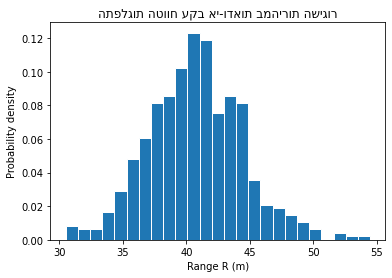

In [1]:
import numpy as np
import matplotlib.pyplot as plt

g, v0 = 9.8, 20.0          # m/s^2, m/s
rng = np.random.default_rng(1)
theta = np.radians(45)

v0_trials = rng.normal(20.0, 1.0, size=500)
R_trials = v0_trials**2 * np.sin(2 * theta) / g

fig, ax = plt.subplots()
ax.hist(R_trials, bins=25, density=True, color="tab:blue", edgecolor="white")
ax.set_xlabel("Range R (m)")
ax.set_ylabel("Probability density")
ax.set_title("התפלגות הטווח עקב אי-ודאות במהירות השיגור")
plt.show()

### נסו בעצמכם

הריצו את אותה היסטוגרמה עם `density=False` במקום `density=True`, והשוו את ציר ה-$y$ — מה משמעות הערכים עכשיו?

In [2]:
# fig, ax = plt.subplots()
# ax.hist(R_trials, bins=25, density=False, ...)
# ...

`````{admonition} פתרון
:class: dropdown, tip
```python
fig, ax = plt.subplots()
ax.hist(R_trials, bins=25, density=False, color="tab:blue", edgecolor="white")
ax.set_xlabel("Range R (m)")
ax.set_ylabel("Number of measurements")
plt.show()
```
כעת ציר ה-$y$ מציג את **מספר הזריקות הגולמי** שנפל בכל תא, ולא צפיפות הסתברות — הסכום הכולל של העמודות שווה ל-500 (מספר הזריקות), ולא 1.
`````

### באג נפוץ: תווית `"צפיפות"` כש-`density=False`

אם משאירים את התווית `"צפיפות הסתברות"` על ציר $y$ בזמן שקוראים ל-`ax.hist` עם `density=False` (ברירת המחדל) — התווית שגויה: הערכים בפועל הם ספירה גולמית, לא צפיפות. יש לוודא תמיד שהתווית תואמת את הפרמטר בפועל.

### בדקו את עצמכם

In [3]:
from jupyterquiz import display_quiz

questions = [
    {
        "question": "מה משמעות <code>density=True</code> ב-<code>ax.hist</code>?",
        "type": "multiple_choice",
        "answers": [
            {"answer": "ציר ה-y מציג מספר מדידות גולמי בכל תא", "correct": False, "feedback": "זו המשמעות של density=False."},
            {"answer": "ה-bins נקבעים אוטומטית לפי כלל שונה", "correct": False, "feedback": "לא — density לא קובעת את מספר התאים."},
            {"answer": "ציר ה-y מוצג בסולם לוגריתמי", "correct": False, "feedback": "לא — density לא קובעת סולם; היא רק משנה את הנרמול של הגובה."},
            {"answer": "ציר ה-y מנורמל כך שהשטח הכולל מתחת להיסטוגרמה שווה 1", "correct": True, "feedback": "נכון."}
        ]
    }
]
display_quiz(questions)

<IPython.core.display.Javascript object>

### תרגול עצמי

הציגו על אותו גרף שתי היסטוגרמות שקופות למחצה (`alpha=0.5`) — התפלגות הטווח עבור $\theta=45^\circ$ ועבור $\theta=30^\circ$ (עם אותו רעש במהירות), עם מקרא.

In [4]:
# theta2 = np.radians(30)
# ...

`````{admonition} פתרון
:class: dropdown, tip
```python
theta2 = np.radians(30)
R_trials_2 = v0_trials**2 * np.sin(2 * theta2) / g

fig, ax = plt.subplots()
ax.hist(R_trials, bins=25, density=True, alpha=0.5, label=r"$\theta=45^\circ$")
ax.hist(R_trials_2, bins=25, density=True, alpha=0.5, label=r"$\theta=30^\circ$")
ax.set_xlabel("Range R (m)")
ax.set_ylabel("Probability density")
ax.legend()
plt.show()
```
`````